1. [真实素数] 生成并归一化 (N=20000000)...
2. [静态模型] 生成对照数据...
3. [老化模型] 生成模型数据...
4. 开始绘图 (Figure 5)...


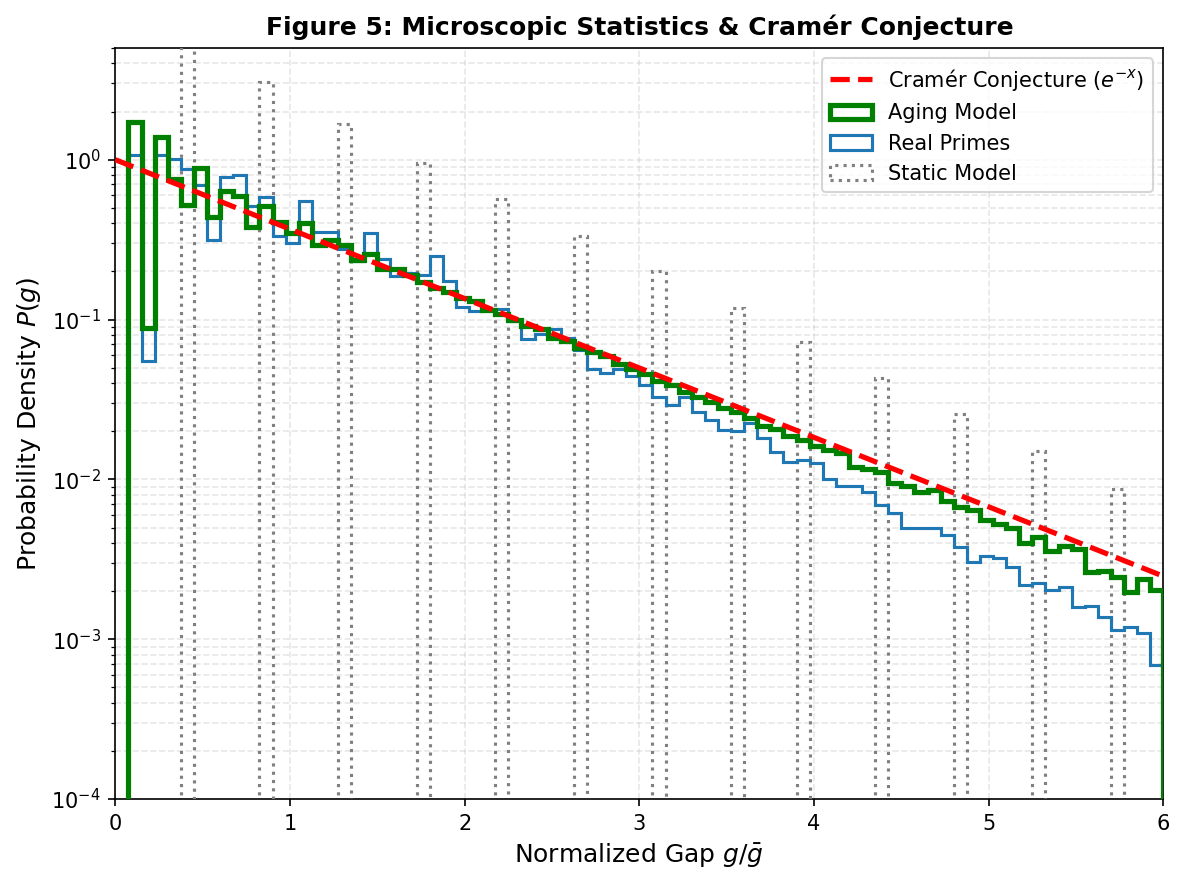

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cramer_test(limit=20000000): # 20M data points
    print(f"1. [Real primes] generating and normalizing (N={limit})...")
    is_prime = np.ones(limit + 1, dtype=bool)
    is_prime[0:2] = False
    for i in range(2, int(limit**0.5) + 1):
        if is_prime[i]:
            is_prime[i*i : limit+1 : i] = False
    primes = np.nonzero(is_prime)[0]
    real_gaps = np.diff(primes)
    
    # Normalization: g / <g> (sliding-window local mean)
    # Window = 2000 for a smooth estimate
    window = 2000
    smooth_real = np.convolve(real_gaps, np.ones(window)/window, mode='same')
    smooth_real[smooth_real == 0] = 1 
    norm_real = real_gaps / smooth_real

    print(f"2. [Static model] generating control data...")
    u = 1.543689012692076
    x = 0.1
    static_gaps = []
    # The static model only needs ~5M points to reveal its distribution
    static_limit = min(limit, 5000000) 
    
    last_t = 0
    for t in range(1, static_limit):
        x = 1 - u * x**2
        if x < 0:
            gap = t - last_t
            if gap > 0: static_gaps.append(gap)
            last_t = t
    static_gaps = np.array(static_gaps)
    # Static model is stationary; divide by the global mean
    norm_static = static_gaps / np.mean(static_gaps)

    print(f"3. [Aging model] generating model data...")
    # Either k=4.5 or 12.74 yields a similar normalized distribution; we use 4.5 to match Fig 4
    # For statistical rigor the physical value 12.74 also works perfectly
    k = 12.74 
    aging_gaps = []
    x = 0.1
    last_t = 0
    
    for t in range(1, limit):
        x = 1 - u * x**2
        if x < 0:
            prob = k / np.log(t + 2)
            if np.random.random() < prob:
                gap = t - last_t
                if gap > 0: aging_gaps.append(gap)
                last_t = t
    
    aging_gaps = np.array(aging_gaps)
    # Normalize the aging-model output
    smooth_aging = np.convolve(aging_gaps.astype(float), np.ones(window)/window, mode='same')
    smooth_aging[smooth_aging == 0] = 1
    norm_aging = aging_gaps / smooth_aging

    # ==========================================
    # 4. Plot
    # ==========================================
    print("4. Plotting...")
    plt.figure(figsize=(8, 6), dpi=150)
    
    # --- 1. Theoretical curve (red dashed) ---
    xx = np.linspace(0, 6, 100)
    plt.plot(xx, np.exp(-xx), 'r--', lw=2.5, label='Cramér Conjecture ($e^{-x}$)', zorder=10)
    
    # --- 2. Aging model (green solid - main focus) ---
    plt.hist(norm_aging, bins=80, density=True, range=(0, 6), 
             histtype='step', lw=2.5, color='#008000', label='Aging Model', zorder=5)
    
    # --- 3. Real primes (blue solid - target) ---
    plt.hist(norm_real, bins=80, density=True, range=(0, 6), 
             histtype='step', lw=1.5, color='#1f77b4', label='Real Primes', zorder=4)

    # --- 4. Static model (grey dotted - control) ---
    # The static model usually shows many "spikes" or has the wrong tail
    plt.hist(norm_static, bins=80, density=True, range=(0, 6), 
             histtype='step', lw=1.5, color='gray', linestyle=':', label='Static Model', zorder=3)

    # Configure axes
    plt.yscale('log') # Log y-axis: standard practice for verifying an exponential distribution
    plt.xlabel('Normalized Gap $g / \\bar{g}$', fontsize=12)
    plt.ylabel('Probability Density $P(g)$', fontsize=12)
    plt.title('Microscopic Statistics & Cramér Conjecture', fontsize=12, fontweight='bold')
    
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, which='both', ls='--', alpha=0.3)
    plt.ylim(1e-4, 5) # Sensible y-range
    plt.xlim(0, 6)    # x-range
    
    plt.tight_layout()
    plt.show()

# Run
plot_cramer_test(limit=20000000)